# The first day decides

A million people a week open a GitHub account. This notebook asks what happens
in their first four weeks, and what separates the ones who stay.

Most of the work is not the answer. It is making sure the question is being
asked of the right people — the obvious way to define "a newcomer" turns out
to be wrong by about three years.

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
from scipy import stats

import activation_figures as figs
import charts
import drivers as drv
from bots import PROCESSED
from cohort import BOUNDARIES, OBSERVATION_DAYS
from data import connect

theme = charts.use("light")
con = connect()
drv.load(con)          # one row per newcomer: day-one features, later outcome
frames = figs.load()

## 1. Who counts as a newcomer?

GH Archive records events, not signups. There is no registration date in it
anywhere.

The obvious substitute is "the first time this account appears in our data".
Before building anything on that, I took 600 accounts that first appeared in
one week and asked GitHub's API when each was actually created.

In [2]:
sample = frames["sample"]
print(f"{len(sample)} accounts resolved")
sample.age_days.describe(percentiles=[0.25, 0.5, 0.75]).round(0).to_frame("days old")

578 accounts resolved


,days old
count,578.0
mean,1475.0
std,1453.0
min,0.0
25%,264.0
50%,1040.0
75%,2333.0
max,6101.0


**The median "newcomer" had held the account for 1,040 days.** Only 8% were
made that day.

So "first seen" mostly finds dormant accounts waking up. Building a cohort
that way would have measured something completely different, and nothing
downstream would have looked wrong.

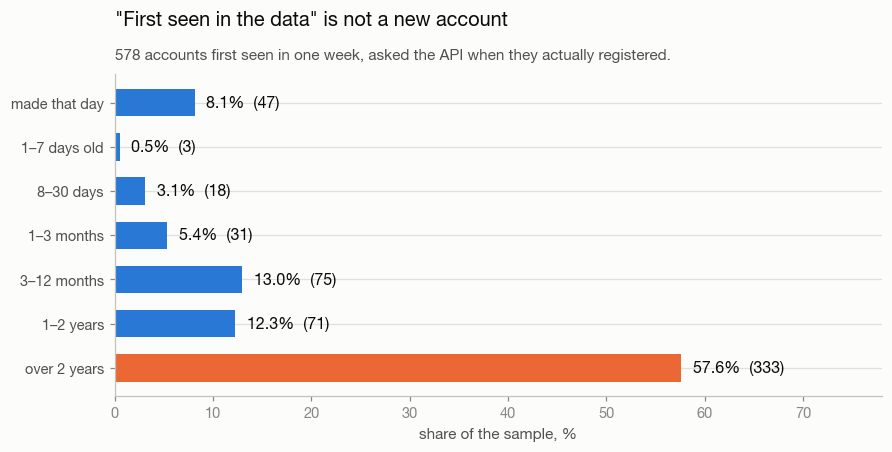

In [3]:
figs.account_ages(sample, theme);

## 2. The fix: account ids are queue tickets

GitHub hands out `actor_id` in registration order. If that holds, a week of
signups is simply a range of ids — and the range can be found exactly instead
of guessed.

Checked on 370 accounts spread across 2025: sorted by id, how many times does
the registration date go *backwards*?

In [4]:
cal = pd.read_parquet(PROCESSED / "id_calibration.parquet").sort_values("actor_id")
print(f"{len(cal)} accounts checked")
print(f"dates going backwards: {(cal.created_at.diff().dt.days < 0).sum()}")

370 accounts checked
dates going backwards: 0


Zero. So `src/cohort.py` binary-searches the API for the first id issued on
each Monday, which pins the boundary exactly rather than to within a sample's
resolution.

In [5]:
pd.read_parquet(BOUNDARIES)

,week,first_id,last_id,ids_in_week
0,2025-06-02,214410595,215433105,1022511
1,2025-06-09,215433106,216457072,1023967
2,2025-06-16,216457073,217513655,1056583
3,2025-06-23,217513656,218523106,1009451
4,2025-06-30,218523107,219586225,1063119
5,2025-07-07,219586226,220644919,1058694
6,2025-07-14,220644920,221909214,1264295
7,2025-07-21,221909215,223178187,1268973
8,2025-07-28,223178188,224471939,1293752


### Then check the boundaries, rather than trusting them

For every boundary I pulled 12 resolvable accounts just below it and 12 just
at or above it, and asked whether each was created on the right side.

**216 of 216 were correct.** The cohorts are exact.

## 3. The funnel

One clock for everyone: days since the Monday their account was made.
Automation is stripped out first with the rules from the data-quality case
study — new accounts are exactly where the push farms live.

Two definitions worth saying out loud:

* **28 days, not 30.** Returns bump on days 7, 14, 21 and 28 — people come
  back on the weekday they arrived. A window that is not whole weeks gives
  different cohorts different numbers of weekends.
* **A second *day*, not a second event.** Half of all newcomers fire several
  events within minutes of their first. That is one sitting, not a return.

In [6]:
weekly = frames["weekly"]
weekly

,week,ids_in_week,acted,came_back,acted_pct,activation_pct
0,2025-06-02,1022511,172669,54156,16.9,31.4
1,2025-06-09,1023967,166977,54174,16.3,32.4
2,2025-06-16,1056583,170237,57037,16.1,33.5
3,2025-06-23,1009451,165259,56397,16.4,34.1
4,2025-06-30,1063119,165848,54767,15.6,33.0
5,2025-07-07,1058694,166759,54027,15.8,32.4
6,2025-07-14,1264295,170742,59030,13.5,34.6
7,2025-07-21,1268973,174218,58244,13.7,33.4
8,2025-07-28,1293752,174226,58128,13.5,33.4


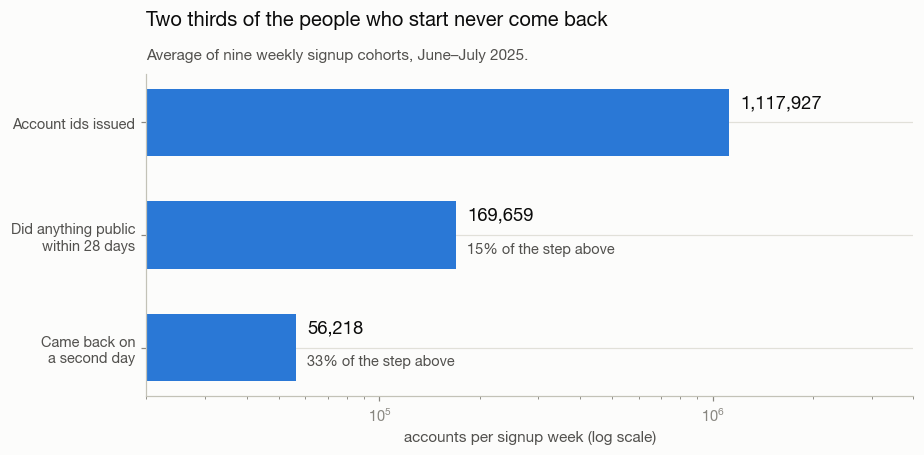

In [7]:
figs.funnel(weekly, theme);

Of the people who do anything at all, **a third come back on a second day** —
and that number holds across all nine weeks (31.4% to 34.6%), so it is not one
odd week.

## 4. What separates them — and the trap

The obvious move is to compare people who did X against people who did not.
The trap is that eager newcomers do more of *everything* and come back more
often, so every feature looks helpful.

So each comparison is run twice: raw, and again inside bands of how much the
account did on its first day.

In [8]:
con.sql("""
    SELECT band AS day_one_events, count(*) AS accounts,
           round(100.0 * avg(came_back::INT), 1) AS came_back_pct
    FROM newcomers GROUP BY 1 ORDER BY min(events)
""").df()

,day_one_events,accounts,came_back_pct
0,1,620666,25.9
1,2-3,546337,33.0
2,4-10,293302,43.5
3,11+,66630,56.7


In [9]:
gaps = frames["gaps"]
gaps

,on day one they…,share of newcomers,raw gap,same-volume gap
2,got a reply from someone,1.4,13.2,12.1
0,pushed code,38.4,16.4,11.3
1,opened a pull request,2.1,15.0,10.4
3,commented,1.3,-1.7,-2.3
5,forked a repository,7.7,-6.3,-3.7
7,touched someone else's repository,22.7,-8.9,-5.0
4,opened an issue,2.4,-6.8,-6.2
6,starred a repository,10.2,-12.1,-8.8


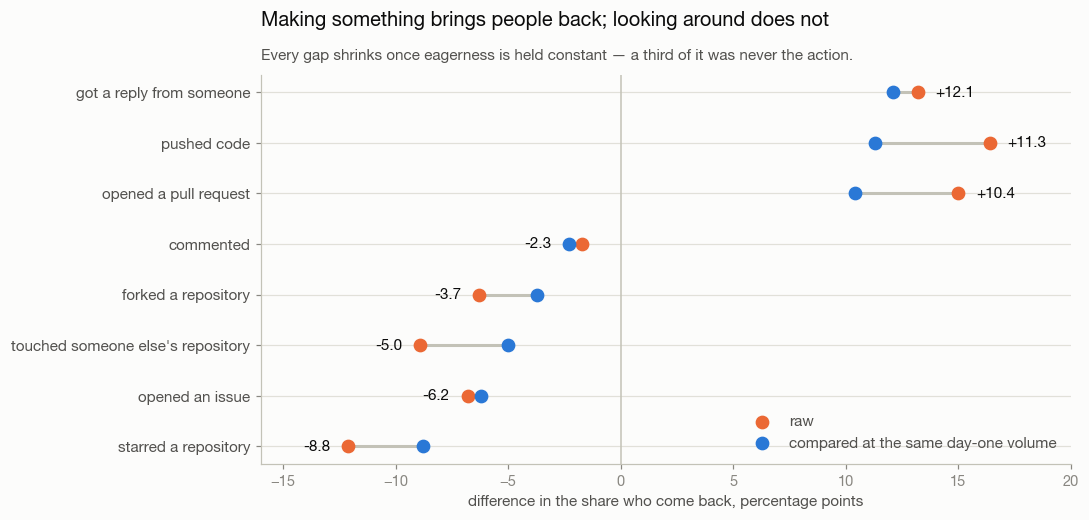

In [10]:
figs.driver_gaps(gaps, theme);

Roughly a third of every raw gap was eagerness rather than the action. What
survives still points one way:

**Newcomers who make something come back. Newcomers who look at other people's
work do not.** Starring is the strongest negative signal in the data — which
means any "getting started" flow that walks people around to explore and star
things is walking them toward the exit.

## 5. The one lever that barely shrinks

Getting a reply is the only feature that survives matching almost intact
(+13.2 raw, +12.1 matched). That makes sense: how many events you fire is
yours to control, whether a stranger answers you is not.

Tested properly — only among newcomers who posted something a person *could*
reply to, because comparing against everyone else would mostly compare posters
with non-posters.

In [11]:
con.sql("""
    SELECT posted_something, count(*) AS accounts,
           round(100.0 * avg(got_a_reply::INT), 1) AS got_a_reply_pct
    FROM newcomers GROUP BY 1 ORDER BY 1
""").df()

,posted_something,accounts,got_a_reply_pct
0,False,1446783,0.3
1,True,80152,21.2


Only 5.2% of newcomers post anything repliable at all — and of those, **only
one in five gets an answer.**

In [12]:
table, odds, p = drv.reply_effect(con)
print(f"odds ratio {odds:.2f}, Fisher exact p = {p:.1e}")
table

odds ratio 1.39, Fisher exact p = 1.4e-77


,no reply %,got a reply %,"gap, pts",n no reply,n got a reply
band,,,,,
1,20.0,30.6,10.6,21759,6910
2-3,30.2,40.4,10.2,14094,4716
4-10,42.0,52.3,10.3,19908,3935
11+,54.9,63.0,8.1,7418,1412


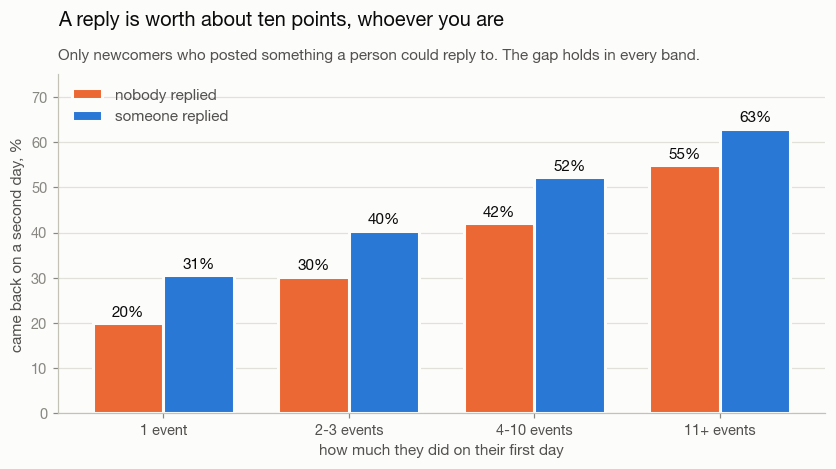

In [13]:
figs.reply_effect(table, theme);

Consistent in every band: +10.6, +10.2, +10.3, +8.1 points. The effect is not
an artefact of eager people getting more replies.

## What I would change

**Route a first-time contributor's first post to a human within 24 hours.**
They are identifiable the moment they post: `author_association` is `NONE` and
the account id says the account is days old. A maintainer nudge, a triage
queue, a first-timer label — whatever gets an answer in front of them.

**Stop counting stars and forks as onboarding progress.** They are the
strongest negative signal here.

**Point the first-run flow at making something.** Pushing code on day one is
worth +11.3 points and reaches 38% of newcomers — the widest lever in this
data.

### How I would test it

Randomise newcomers who post on day one and get no reply within a few hours;
treatment surfaces the post to a maintainer. The observed gap is 8–10 points,
but it is correlational, so plan for less.

In [14]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
import math

base, weekly_eligible = 0.333, 63179 / 9
rows = []
for lift in (0.02, 0.03, 0.05):
    n = math.ceil(NormalIndPower().solve_power(
        effect_size=proportion_effectsize(base + lift, base),
        power=0.8, alpha=0.05, ratio=1, alternative="two-sided"))
    rows.append({"detect": f"+{lift*100:.0f} points", "per arm": n,
                 "weeks of newcomers": round(2 * n / weekly_eligible, 1)})
pd.DataFrame(rows)

,detect,per arm,weeks of newcomers
0,+2 points,8843,2.5
1,+3 points,3956,1.1
2,+5 points,1442,0.4


At +3 points the test reads out in about a week and a half of newcomers. That
is cheap enough that the bigger risk is shipping the change untested.

### What this does not show

The reply effect is **correlational**. A newcomer who posts something
interesting is more likely to get a reply *and* more likely to come back; the
banding removes the volume part of that, not the quality part. That is exactly
why the recommendation ends in a test rather than a promised lift.

The top of the funnel is an estimate — accounts that sign up and never act are
invisible here, so id ranges stand in for signups. And this is June and July
only; a September student intake may behave differently.